2 2


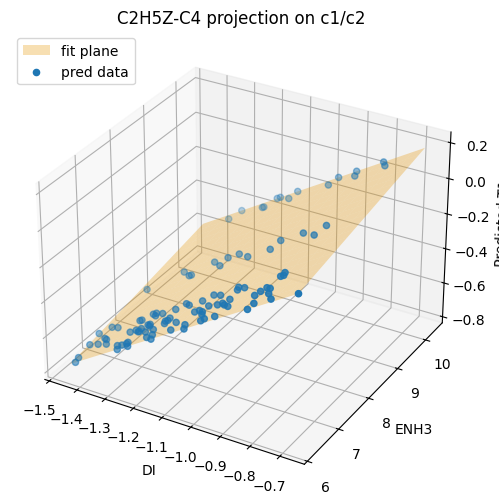

In [29]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from mt_sisso_scatter import _build_task_index
# 配置
selected_task = "C2H5Z-C4"  # 修改为你要看的 task
pred_path = Path("train_predictions.csv")
coef_path = Path("coeffs.csv")

# 读数据
df_pred = pd.read_csv(pred_path)
df_coef = pd.read_csv(coef_path)


# 过滤 task
df_task = df_pred[df_pred["task"] == selected_task].copy()
if df_task.empty:
    raise SystemExit(f"{selected_task} 在 train_predictions.csv 中没有数据")
row_coef = df_coef[df_coef["task"] == selected_task]
if row_coef.empty:
    raise SystemExit(f"{selected_task} 在 coeffs.csv 中没有系数")
# 提取系数与贡献
coef_row = row_coef.iloc[0]
c0 = float(coef_row["c0"])
# 动态获取所有 contrib_i 与对应 ci
contrib_cols = [c for c in df_task.columns if c.startswith("contrib_")]
ci_cols = [c for c in coef_row.index if c.startswith("c") and c != "c0"]
print(len(contrib_cols),len(ci_cols))
if len(contrib_cols) < 2 or len(ci_cols) < 2:
    raise SystemExit("至少需要 c1/c2 和 contrib_1/contrib_2")

df_task["zeotype"] = [m.split('_')[0] for m in df_task['materials'] ]
df_task["mtype"] = [m.split('_')[1] for m in df_task['materials'] ]


c1 = float(coef_row["c1"]); c2 = float(coef_row["c2"])
d1 = df_task["contrib_1"] / c1
d2 = df_task["contrib_2"] / c2
df_task["d1"] = d1  #ENH3
df_task["d2"] = d2  ##DI

# 部分 2：c1/c2 投影平面
fig = plt.figure(figsize=(7, 6))
ax3d = fig.add_subplot(111, projection="3d")

# 平面网格
x_range = np.linspace(df_task["d1"].min(), df_task["d1"].max(), 20)
y_range = np.linspace(df_task["d2"].min(), df_task["d2"].max(), 20)
X, Y = np.meshgrid(x_range, y_range)
Z = c0 + c1 * X + c2 * Y

ax3d.plot_surface(X, Y, Z, alpha=0.3, color="orange", linewidth=0, label="fit plane")
ax3d.scatter(df_task["d1"], df_task["d2"], df_task["pred_T1"], color="tab:blue", s=20, label="pred data")
ax3d.set_xlabel("DI"); ax3d.set_ylabel("ENH3"); ax3d.set_zlabel("Predicted T1")
ax3d.set_title(f"{selected_task} projection on c1/c2")

# 简单图例处理
handles, labels = ax3d.get_legend_handles_labels()
if handles:
    ax3d.legend(handles, labels, loc="upper left")

plt.show()


# # 部分 1：真实 vs 预测
# fig, ax = plt.subplots(figsize=(6, 5))
# ax.scatter(df_task["true_T1"], df_task["pred_T1"], s=20, alpha=0.7, color="tab:blue", label="data")
# min_v = min(df_task["true_T1"].min(), df_task["pred_T1"].min())
# max_v = max(df_task["true_T1"].max(), df_task["pred_T1"].max())
# pad = (max_v - min_v) * 0.05 if max_v > min_v else 0.1
# ax.plot([min_v - pad, max_v + pad], [min_v - pad, max_v + pad], "k--", lw=1, label="y=x")
# ax.set_xlim(min_v - pad, max_v + pad); ax.set_ylim(min_v - pad*2, max_v + pad*2)
# ax.set_xlabel("True T1"); ax.set_ylabel("Predicted T1")
# ax.set_title(f"{selected_task} True vs Pred")
# ax.legend()
# plt.show()


['ANO-O2' 'PTT' 'SAS' 'EAB' 'AEI-O1' 'ERI' 'IFY' 'LTA' 'CHA-O1' 'AEI-O2'
 'RHO' 'AVL' 'CHA-O2' 'AFX' 'SAV']


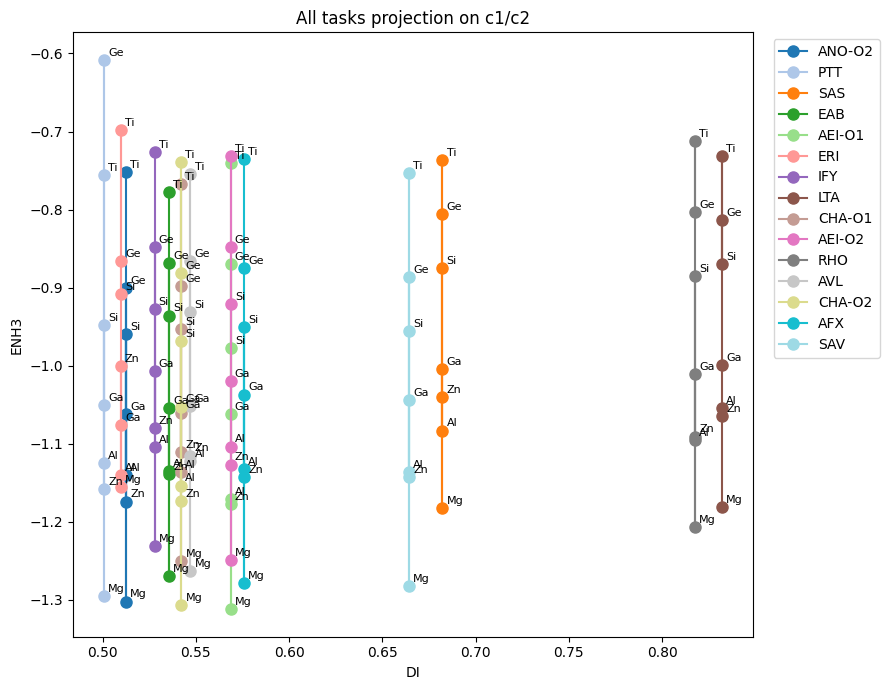

In [207]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pred_path = Path("train_predictions.csv")
coef_path = Path("coeffs.csv")

df_pred = pd.read_csv(pred_path)
df_coef = pd.read_csv(coef_path)
    # print(sub['materials'].unique())
df_pred["zeotype"] = [m.split('_')[0] for m in df_pred['materials'] ]
df_pred["mtype"] = [m.split('_')[1] for m in df_pred['materials'] ]

# 仅保留两张表都存在的 task
# tasks = sorted(set(df_pred["task"]) & set(df_coef["task"]))
# tasks = ['C2H5Z-C3', 'C2H5Z-C4', 'C2H5Z-TME']
tasks = ['C3-C3-HZ']
zeotype = df_pred['zeotype'].unique()
print(zeotype)
mtype = df_pred['mtype'].unique()
if not tasks:
    raise SystemExit("没有找到同时出现在预测和系数文件中的 task")
fig = plt.figure(figsize=(9, 7))
# ax3d = fig.add_subplot(111, projection="3d")
ax3d = fig.add_subplot(111)
colors = plt.cm.tab20(np.linspace(0, 1, len(zeotype)))
# for color, task in zip(colors, tasks):
#     sub = df_pred[df_pred["task"] == task].copy()
#     coef_row = df_coef[df_coef["task"] == task].iloc[0]
#     print(f"Processing task: {task} with coefficients: {coef_row.to_dict()}")
#     c0, c1, c2 = float(coef_row["c0"]), float(coef_row["c1"]), float(coef_row["c2"])

#     sub["d1"] = sub["contrib_1"] / c1
#     sub["d2"] = sub["contrib_2"] / c2

#     # 平面
#     x_range = np.linspace(sub["d1"].min(), sub["d1"].max(), 10)
#     y_range = np.linspace(sub["d2"].min(), sub["d2"].max(), 10)
#     X, Y = np.meshgrid(x_range, y_range)
#     Z = c0 + c1 * X + c2 * Y
#     # ax3d.plot_surface(X, Y, Z, alpha=0.15, color=color, linewidth=0)
#     # ax3d.plot_surface(X, Z, alpha=0.15, color=color, linewidth=0)

#     # 数据点d
#     ax3d.scatter(sub["d2"], sub["pred_T1"], color=color, s=18, label=task)
#     for x, y, label in zip(sub["d2"], sub["pred_T1"], sub["zeotype"]):
#         ax3d.annotate(str(label), (x, y), textcoords="offset points", xytext=(3, 3), fontsize=8)
for task in tasks:
    sub = df_pred[df_pred["task"] == task].copy()
    coef_row = df_coef[df_coef["task"] == task].iloc[0]
    # print(f"Processing task: {task} with coefficients: {coef_row.to_dict()}")
    c0, c1, c2 = float(coef_row["c0"]), float(coef_row["c1"]), float(coef_row["c2"])
    sub["d1"] = sub["contrib_1"] / c1
    sub["d2"] = sub["contrib_2"] / c2
    for color, z in zip(colors, zeotype):
        # print(zeo)
        sub_zeo = sub[sub["zeotype"] == z]
        # ax3d.scatter(sub_zeo["contrib_1"], sub_zeo["contrib_2"], color=color, s=18, label=z)
        ax3d.plot(sub_zeo["contrib_2"], sub_zeo["contrib_1"], color=color, marker='o',label=z,markersize=8)

        for x, y, label in zip(sub_zeo["contrib_2"], sub_zeo["contrib_1"], sub_zeo["mtype"]):
            ax3d.annotate(str(label), (x, y), textcoords="offset points", xytext=(3, 3), fontsize=8)

ax3d.set_xlabel("DI")
ax3d.set_ylabel("ENH3")
# ax3d.set_zlabel("Predicted T1")
ax3d.set_title("All tasks projection on c1/c2")
ax3d.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
fig.tight_layout()
plt.show()

['ANO-O2' 'PTT' 'SAS' 'EAB' 'AEI-O1' 'ERI' 'IFY' 'LTA' 'CHA-O1' 'AEI-O2'
 'RHO' 'AVL' 'CHA-O2' 'AFX' 'SAV']


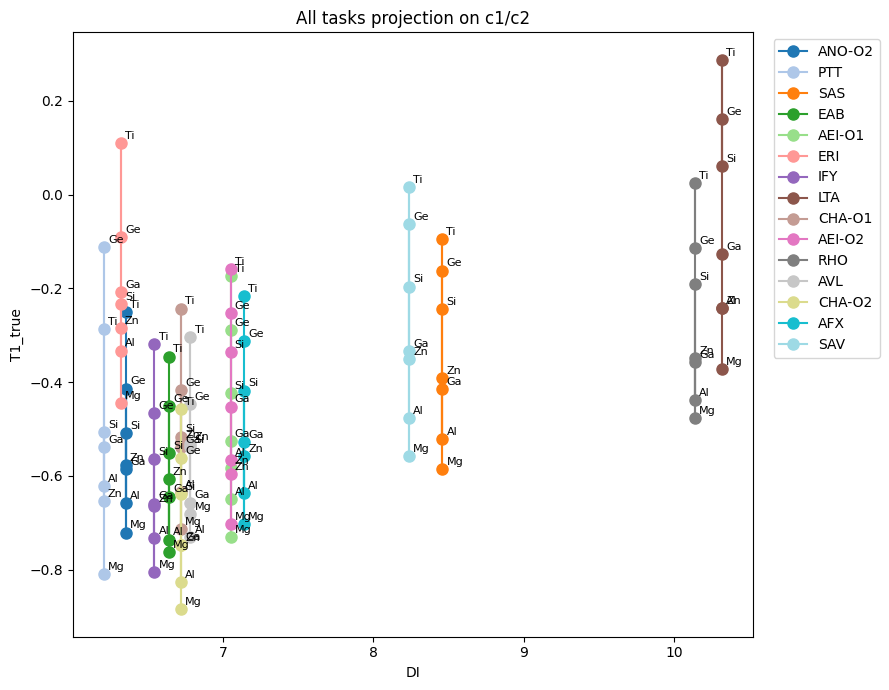

In [13]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pred_path = Path("train_predictions.csv")
coef_path = Path("coeffs.csv")

df_pred = pd.read_csv(pred_path)
df_coef = pd.read_csv(coef_path)
    # print(sub['materials'].unique())
df_pred["zeotype"] = [m.split('_')[0] for m in df_pred['materials'] ]
df_pred["mtype"] = [m.split('_')[1] for m in df_pred['materials'] ]

# 仅保留两张表都存在的 task
# tasks = sorted(set(df_pred["task"]) & set(df_coef["task"]))
# tasks = ['C2H5Z-C3', 'C2H5Z-C4', 'C2H5Z-TME']
tasks = ['C3-C3-HZ']
zeotype = df_pred['zeotype'].unique()
print(zeotype)
mtype = df_pred['mtype'].unique()
if not tasks:
    raise SystemExit("没有找到同时出现在预测和系数文件中的 task")
fig = plt.figure(figsize=(9, 7))
# ax3d = fig.add_subplot(111, projection="3d")
ax3d = fig.add_subplot(111)
colors = plt.cm.tab20(np.linspace(0, 1, len(zeotype)))
# for color, task in zip(colors, tasks):
#     sub = df_pred[df_pred["task"] == task].copy()
#     coef_row = df_coef[df_coef["task"] == task].iloc[0]
#     print(f"Processing task: {task} with coefficients: {coef_row.to_dict()}")
#     c0, c1, c2 = float(coef_row["c0"]), float(coef_row["c1"]), float(coef_row["c2"])

#     sub["d1"] = sub["contrib_1"] / c1
#     sub["d2"] = sub["contrib_2"] / c2

#     # 平面
#     x_range = np.linspace(sub["d1"].min(), sub["d1"].max(), 10)
#     y_range = np.linspace(sub["d2"].min(), sub["d2"].max(), 10)
#     X, Y = np.meshgrid(x_range, y_range)
#     Z = c0 + c1 * X + c2 * Y
#     # ax3d.plot_surface(X, Y, Z, alpha=0.15, color=color, linewidth=0)
#     # ax3d.plot_surface(X, Z, alpha=0.15, color=color, linewidth=0)

#     # 数据点d
#     ax3d.scatter(sub["d2"], sub["pred_T1"], color=color, s=18, label=task)
#     for x, y, label in zip(sub["d2"], sub["pred_T1"], sub["zeotype"]):
#         ax3d.annotate(str(label), (x, y), textcoords="offset points", xytext=(3, 3), fontsize=8)
for task in tasks:
    sub = df_pred[df_pred["task"] == task].copy()
    coef_row = df_coef[df_coef["task"] == task].iloc[0]
    # print(f"Processing task: {task} with coefficients: {coef_row.to_dict()}")
    c0, c1, c2 = float(coef_row["c0"]), float(coef_row["c1"]), float(coef_row["c2"])
    sub["d1"] = sub["contrib_1"] / c1
    sub["d2"] = sub["contrib_2"] / c2
    for color, z in zip(colors, zeotype):
        # print(zeo)
        sub_zeo = sub[sub["zeotype"] == z]
        # ax3d.scatter(sub_zeo["contrib_1"], sub_zeo["contrib_2"], color=color, s=18, label=z)
        ax3d.plot(sub_zeo["d2"], sub_zeo["true_T1"], color=color, marker='o',label=z,markersize=8)

        for x, y, label in zip(sub_zeo["d2"], sub_zeo["true_T1"], sub_zeo["mtype"]):
            ax3d.annotate(str(label), (x, y), textcoords="offset points", xytext=(3, 3), fontsize=8)

ax3d.set_xlabel("DI")
ax3d.set_ylabel("T1_true")
# ax3d.set_zlabel("Predicted T1")
ax3d.set_title("All tasks projection on c1/c2")
ax3d.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
fig.tight_layout()
plt.show()

['ANO-O2', 'PTT', 'SAS', 'EAB', 'AEI-O1', 'ERI', 'IFY', 'LTA', 'CHA-O1', 'AEI-O2', 'RHO', 'AVL', 'CHA-O2', 'AFX', 'SAV']
0.898377705 1.025533534 0.01897979036
Task: C2H5Z-C3
1.0273245009355823 0.0
ANO-O2 y = 1.15 + 1.03 * ENH3 + 0.0 * DI^-1  r2 = 0.99
0.9867670038085861 0.0
PTT y = 1.07 + 0.99 * ENH3 + 0.0 * DI^-1  r2 = 1.00
1.0890932819267845 0.0
SAS y = 1.14 + 1.09 * ENH3 + 0.0 * DI^-1  r2 = 0.95
1.1359769661098984 0.0
EAB y = 1.16 + 1.14 * ENH3 + 0.0 * DI^-1  r2 = 1.00
1.0086384035529274 0.0
AEI-O1 y = 1.08 + 1.01 * ENH3 + 0.0 * DI^-1  r2 = 1.00
1.046853512152923 0.0
ERI y = 0.95 + 1.05 * ENH3 + 0.0 * DI^-1  r2 = 0.95
1.0010502656046663 0.0
IFY y = 1.03 + 1.00 * ENH3 + 0.0 * DI^-1  r2 = 1.00
1.0468325448859925 0.0
LTA y = 1.21 + 1.05 * ENH3 + 0.0 * DI^-1  r2 = 0.98
0.9690279200300193 0.0
CHA-O1 y = 1.00 + 0.97 * ENH3 + 0.0 * DI^-1  r2 = 0.97
1.0166055111611847 0.0
AEI-O2 y = 0.99 + 1.02 * ENH3 + 0.0 * DI^-1  r2 = 0.99
0.9733962869443689 0.0
RHO y = 0.99 + 0.97 * ENH3 + 0.0 * DI^-1  

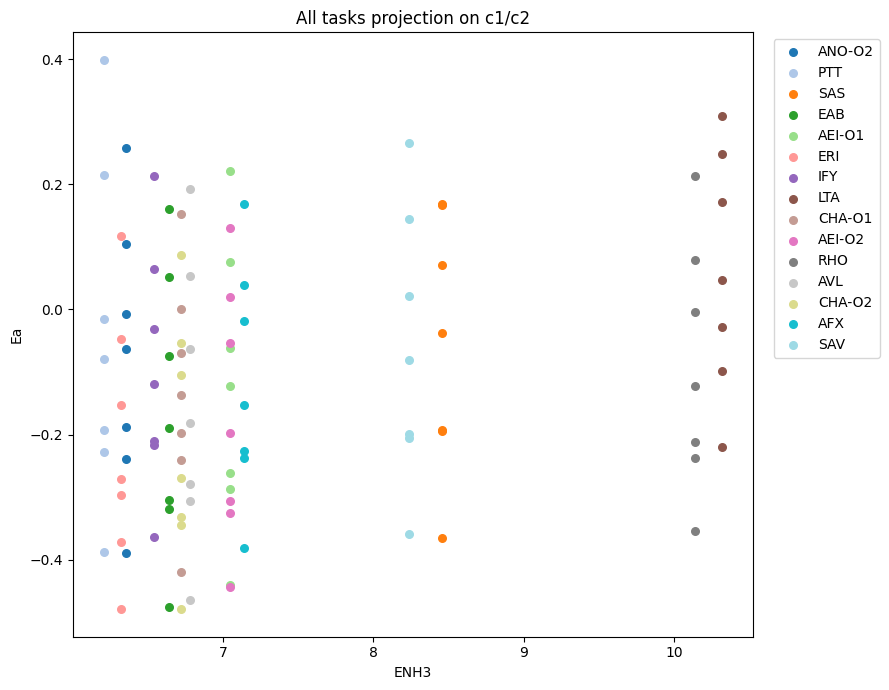

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
import numpy as np

pred_path = Path("./train_predictions.csv")
coef_path = Path("./coeffs.csv")

df_pred = pd.read_csv(pred_path)
df_coef = pd.read_csv(coef_path)
    # print(sub['materials'].unique())
df_pred["zeotype"] = [m.split('_')[0] for m in df_pred['materials'] ]
df_pred["mtype"] = [m.split('_')[1] for m in df_pred['materials'] ]
print(df_pred["zeotype"].unique().tolist())
# 仅保留两张表都存在的 task
# tasks = sorted(set(df_pred["task"]) & set(df_coef["task"]))
# tasks = ['CH3OH-CO','CH3OH-C2','CH3OH-C3','CH3OH-C4','CH3OH-NH3','CH3OH-TME','CH3OH-Toluene']
tasks = ['C2H5Z-C3']
# tasks = df_coef['task'].unique().tolist()
# zeo_selected = ['CHA-O1']
zeo_selected = df_pred["zeotype"].unique().tolist()
# zeo_selecte = ['RHO','SAS']
zeotype = df_pred['zeotype'].unique().tolist()
# print(zeotype)
mtype = df_pred['mtype'].unique()
if not tasks:
    raise SystemExit("没有找到同时出现在预测和系数文件中的 task")
fig = plt.figure(figsize=(9, 7))
# ax3d = fig.add_subplot(111, projection="3d")
ax3d = fig.add_subplot(111)
colors = plt.cm.tab20(np.linspace(0, 1, len(zeotype)))
for task in tasks:
    sub = df_pred[df_pred["task"] == task].copy()
    coef_row = df_coef[df_coef["task"] == task].iloc[0]
    # print(f"Processing task: {task} with coefficients: {coef_row.to_dict()}")
    c0, c1, c2= float(coef_row["c0"]), float(coef_row["c1"]), float(coef_row["c2"])
    print(c0, c1, c2)
    sub["d1"] = sub["contrib_1"] / c1
    sub["d2"] = sub["contrib_2"] / c2

    # sub["d3"] = sub["contrib_3"] / c3
    print(f"Task: {task}")
    for color, z in zip(colors, zeotype):
            sub_zeo = sub[sub["zeotype"] == z]
            X = sub_zeo[["d1","d2"]].values
            y = sub_zeo['true_T1'].values
            model = LinearRegression().fit(X, y)
            n0 = model.intercept_
            n1, n2= model.coef_
            print(n1,n2)
            # x_range = np.linspace(sub_zeo["contrib_1"].min(), sub_zeo["contrib_1"].max(), 100)
            # k,b = np.polyfit(sub_zeo["contrib_1"], sub_zeo["true_T1"], 1)
            # Y = k * x_range + b
            y_pred = model.predict(X)
            R2 = r2_score(sub_zeo["true_T1"], y_pred)
            ax3d.scatter(sub_zeo["d2"], sub_zeo["true_T1"], color=color, s=30, label=z)
            # ax3d.plot(X, y, '--', color=color,linewidth = 2)
            # R2 = r2_score(sub_zeo["true_T1"], k*sub_zeo["contrib_1"] + b)
            # ax3d.text(
            #     x_range[len(x_range)//2],      # 公式标注的 x 位置
            #     Y[len(Y)//2],                  # 公式标注的 y 位置
            #     f"{task} y = {n0:.2f} + {n1:.2f}ENH3 + {n2:.2f}DI  r2 = {R2:.2f}",    # 公式内容
            #     fontsize=14,
            #     color=color
            # )
            print(f"{z} y = {n0:.2f} + {n1:.2f} * ENH3 + {n2} * DI^-1  r2 = {R2:.2f}")

        # for x, y, label in zip(sub_zeo["contrib_1"], sub_zeo["true_T1"], sub_zeo["mtype"]):
        #     ax3d.annotate(str(label), (x, y), textcoords="offset points", xytext=(3, 3), fontsize=8)

        

ax3d.set_xlabel("ENH3")
ax3d.set_ylabel("Ea")
# ax3d.set_zlabel("Predicted T1")
ax3d.set_title("All tasks projection on c1/c2")
ax3d.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
fig.tight_layout()
plt.show()

/var/folders/36/gl3ryvx95t9404brkphk8v680000gn/T/ipykernel_27588/2137136562.py:12: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  train_df = pd.read_csv(train_path, delim_whitespace=True)
/var/folders/36/gl3ryvx95t9404brkphk8v680000gn/T/ipykernel_27588/2137136562.py:64: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/36/gl3ryvx95t9404brkphk8v680000gn/T/ipykernel_27588/2137136562.py:64: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


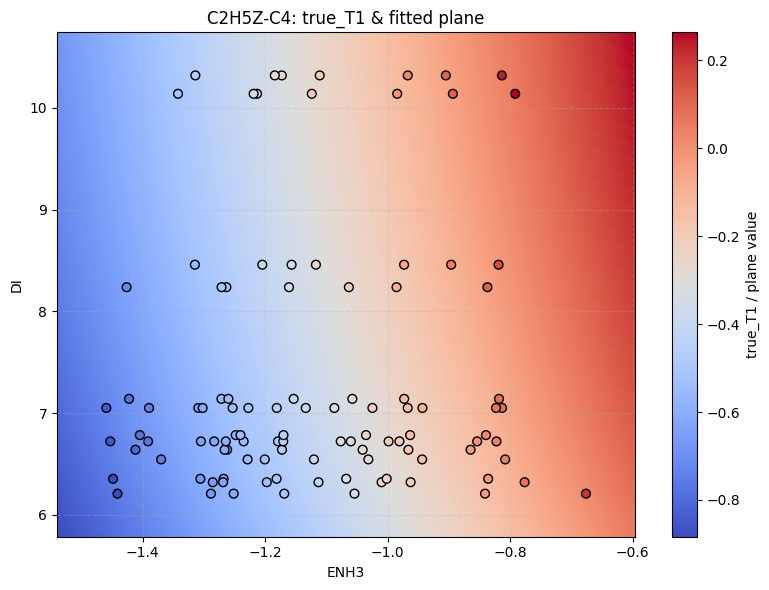

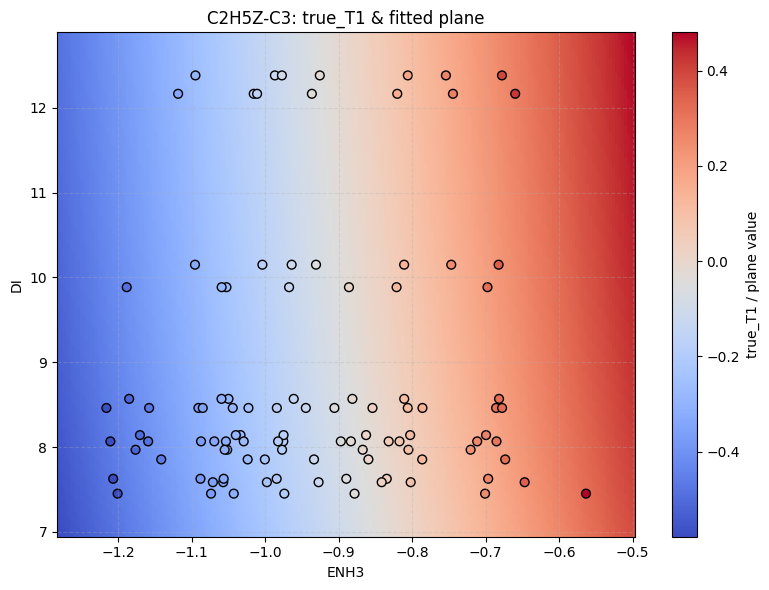

In [355]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path
from matplotlib.colors import TwoSlopeNorm, Normalize

pred_path = Path("./train_predictions_9.csv")
coef_path = Path("./coeffs_9.csv")
train_path = Path("./train.dat")
pred_df = pd.read_csv(pred_path)
coef_df = pd.read_csv(coef_path)
train_df = pd.read_csv(train_path, delim_whitespace=True)
# print(train_df)
pred_df["zeotype"] = [m.split("_")[0] for m in pred_df["materials"]]
pred_df["mtype"] = [m.split("_")[1] for m in pred_df["materials"]]

tasks = [
    "C2H5Z-C4",
    "C2H5Z-C3"
]

out_dir = pred_path.parent

for task in tasks:
    sub = pred_df[pred_df["task"] == task].copy()
    if sub.empty:
        print(f"Skip {task}: no rows in predictions")
        continue
    coef_row = coef_df[coef_df["task"] == task]
    if coef_row.empty:
        print(f"Skip {task}: no coefficients")
        continue

    c0, c1, c2 = map(float, coef_row.iloc[0][["c0", "c1", "c2"]])
    # print(f"Processing {task} with coefficients: c0={c0}, c1={c1}, c2={c2}")
    # 数据范围 + 少量 padding
    sub["d1"] = sub["contrib_1"] / c1 /6
    sub["d2"] = 6/ sub["contrib_2"] * c2 
    x = sub["d1"].to_numpy()
    y = sub["d2"].to_numpy()
    x_pad = (x.max() - x.min()) * 0.1 if len(x) > 1 else 0.1
    y_pad = (y.max() - y.min()) * 0.1 if len(y) > 1 else 0.1
    x_lin = np.linspace(x.min() - x_pad, x.max() + x_pad, 200)
    y_lin = np.linspace(y.min() - y_pad, y.max() + y_pad, 200)
    xx, yy = np.meshgrid(x_lin, y_lin)
    # mask = train_df["materials"] == sub["task"]  # sub["materials"] 需是标量或同长度布尔
    nn = 6
    zz = c0 + c1 * nn * xx + c2 * nn / yy  # 填充平面

    # 色标：跨 0 用 TwoSlopeNorm，否则线性
    values = np.concatenate([zz.ravel(), sub["true_T1"].values])
    vmin, vmax = values.min(), values.max()
    # norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax) if (vmin < 0 < vmax) else Normalize(vmin=vmin, vmax=vmax)

    fig, ax = plt.subplots(figsize=(8, 6))
    hm = ax.pcolormesh(xx, yy, zz, cmap="coolwarm", shading="auto")
    ax.scatter(x, y, c=sub["pred_T1"], cmap="coolwarm", edgecolor="k", s=40)
    ax.set_xlabel("ENH3")
    ax.set_ylabel("DI")
    ax.set_title(f"{task}: true_T1 & fitted plane")
    fig.colorbar(hm, ax=ax, label="true_T1 / plane value")
    ax.grid(True, linestyle="--", alpha=0.3)
    fig.tight_layout()
    fig.show()
    # out_file = out_dir / f"heatmap_{task.replace('/', '-')}.png"
    # fig.savefig(out_file, dpi=300)
    # plt.close(fig)
    # print(f"Saved {out_file}")


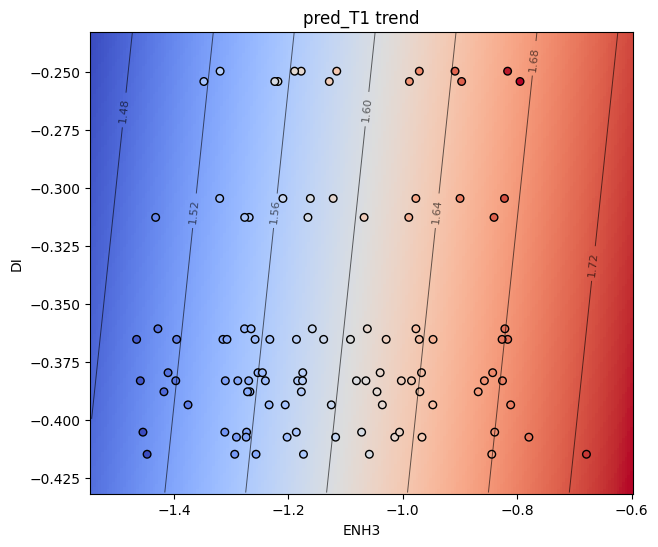

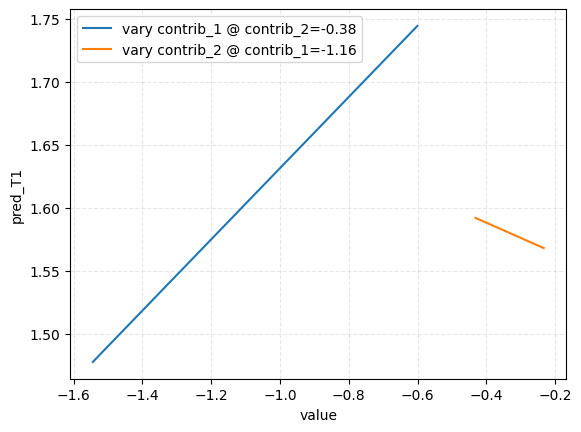

In [338]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

sub = pred_df[pred_df["task"] == "C2H5Z-C4"].copy()
c0, c1, c2 = map(float, coef_df[coef_df["task"]=="CH3OH-CO"][["c0","c1","c2"]].iloc[0])
sub["d1"] = sub["contrib_1"] / c1
sub["d2"] = sub["contrib_2"] / c2
x, y = sub["contrib_1"].to_numpy(), sub["contrib_2"].to_numpy()
x_pad = (x.max() - x.min()) * 0.1 if len(x) > 1 else 0.1
y_pad = (y.max() - y.min()) * 0.1 if len(y) > 1 else 0.1
x_lin = np.linspace(x.min() - x_pad, x.max() + x_pad, 200)
y_lin = np.linspace(y.min() - y_pad, y.max() + y_pad, 200)
# x_lin = np.linspace(x.min(), x.max(), 200)
# y_lin = np.linspace(y.min(), y.max(), 200)
xx, yy = np.meshgrid(x_lin, y_lin)
zz = c0 + c1*xx + c2*yy

# norm = TwoSlopeNorm(vmin=zz.min(), vcenter=0, vmax=zz.max())
fig, ax = plt.subplots(figsize=(7,6))
ax.pcolormesh(xx, yy, zz, cmap="coolwarm", shading="auto")
cs = ax.contour(xx, yy, zz, colors="k", linewidths=0.7, alpha=0.6)
ax.clabel(cs, inline=True, fontsize=8)
ax.scatter(x, y, c=sub["pred_T1"], cmap="coolwarm", edgecolor="k", s=30)
ax.set_xlabel("ENH3"); ax.set_ylabel("DI"); ax.set_title("pred_T1 trend")

# 切片比较斜率
fig2, ax2 = plt.subplots()
y_mid = np.median(y); x_mid = np.median(x)
ax2.plot(x_lin, c0 + c1*x_lin + c2*y_mid, label=f"vary contrib_1 @ contrib_2={y_mid:.2f}")
ax2.plot(y_lin, c0 + c1*x_mid + c2*y_lin, label=f"vary contrib_2 @ contrib_1={x_mid:.2f}")
ax2.set_xlabel("value"); ax2.set_ylabel("pred_T1"); ax2.legend(); ax2.grid(True, ls="--", alpha=0.3)
plt.show()


In [16]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pred_path = Path("train_predictions.csv")
coef_path = Path("coeffs.csv")

df_pred = pd.read_csv(pred_path)
df_coef = pd.read_csv(coef_path)
    # print(sub['materials'].unique())
df_pred["zeotype"] = [m.split('_')[0] for m in df_pred['materials'] ]
df_pred["mtype"] = [m.split('_')[1] for m in df_pred['materials'] ]

# 仅保留两张表都存在的 task
tasks = sorted(set(df_pred["task"]) & set(df_coef["task"]))
# tasks = ['C2H5Z-C3', 'C2H5Z-C4', 'C2H5Z-TME']
# tasks = ['C2H5Z-C4']
zeotype = df_pred['zeotype'].unique()
print(zeotype)
mtype = df_pred['mtype'].unique()
if not tasks:
    raise SystemExit("没有找到同时出现在预测和系数文件中的 task")
fig = plt.figure(figsize=(8, ))
# ax3d = fig.add_subplot(111, projection="3d")
ax3d = fig.add_subplot(111)
colors = plt.cm.tab20(np.linspace(0, 1, len(zeotype)))
# for color, task in zip(colors, tasks):
#     sub = df_pred[df_pred["task"] == task].copy()
#     coef_row = df_coef[df_coef["task"] == task].iloc[0]
#     print(f"Processing task: {task} with coefficients: {coef_row.to_dict()}")
#     c0, c1, c2 = float(coef_row["c0"]), float(coef_row["c1"]), float(coef_row["c2"])

#     sub["d1"] = sub["contrib_1"] / c1
#     sub["d2"] = sub["contrib_2"] / c2

#     # 平面
#     x_range = np.linspace(sub["d1"].min(), sub["d1"].max(), 10)
#     y_range = np.linspace(sub["d2"].min(), sub["d2"].max(), 10)
#     X, Y = np.meshgrid(x_range, y_range)
#     Z = c0 + c1 * X + c2 * Y
#     # ax3d.plot_surface(X, Y, Z, alpha=0.15, color=color, linewidth=0)
#     # ax3d.plot_surface(X, Z, alpha=0.15, color=color, linewidth=0)

#     # 数据点d
#     ax3d.scatter(sub["d2"], sub["pred_T1"], color=color, s=18, label=task)
#     for x, y, label in zip(sub["d2"], sub["pred_T1"], sub["zeotype"]):
#         ax3d.annotate(str(label), (x, y), textcoords="offset points", xytext=(3, 3), fontsize=8)
for task in tasks:
    sub = df_pred[df_pred["task"] == task].copy()
    coef_row = df_coef[df_coef["task"] == task].iloc[0]
    # print(f"Processing task: {task} with coefficients: {coef_row.to_dict()}")
    c0, c1, c2 = float(coef_row["c0"]), float(coef_row["c1"]), float(coef_row["c2"])
    sub["d1"] = sub["contrib_1"] / c1
    sub["d2"] = sub["contrib_2"] / c2
    for color, z in zip(colors, zeotype):
        # print(zeo)
        if z == 'LTA':
            sub_zeo = sub[sub["zeotype"] == z]
            k, b = np.polyfit(sub_zeo["d1"], sub_zeo["true_T1"], 1)
            x_range = np.linspace(sub_zeo["d1"].min(), sub_zeo["d1"].max(), 10)
            Y = k * x_range + b

            ax3d.plot(x_range, Y, '--',color=color)
            ax3d.scatter(sub_zeo["d1"], sub_zeo["true_T1"], color=color, s=18, label=z)
        # ax3d.plot(sub_zeo["contrib_2"], sub_zeo["contrib_1"], color=color, marker='o',label=z,markersize=8)

        # for x, y, label in zip(sub_zeo["contrib_2"], sub_zeo["contrib_1"], sub_zeo["mtype"]):
        #     ax3d.annotate(str(label), (x, y), textcoords="offset points", xytext=(3, 3), fontsize=8)
        else:
            continue
ax3d.set_xlabel("ENH3")
ax3d.set_ylabel("T2")
# ax3d.set_zlabel("Predicted T1")
ax3d.set_title("All tasks projection on c1/c2")
ax3d.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
fig.tight_layout()
plt.show()

['ANO-O2' 'PTT' 'SAS' 'EAB' 'AEI-O1' 'ERI' 'IFY' 'LTA' 'CHA-O1' 'AEI-O2'
 'RHO' 'AVL' 'CHA-O2' 'AFX' 'SAV']


TypeError: Bbox.from_bounds() missing 1 required positional argument: 'height'

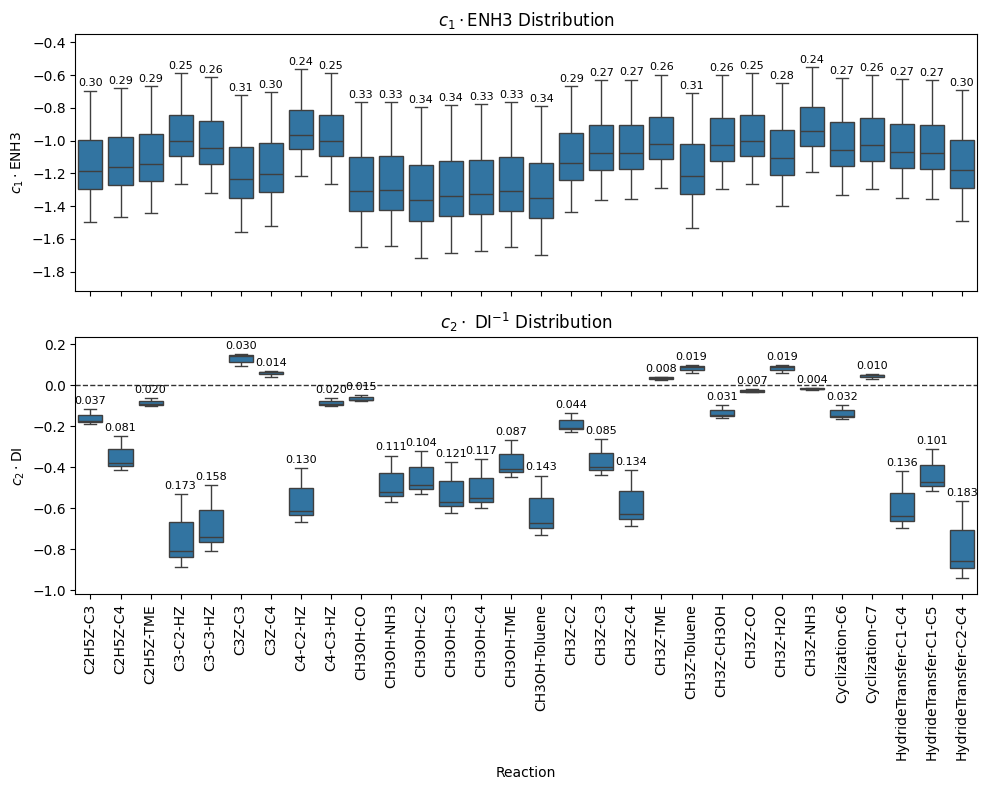

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

# 读取文件
df_pred = pd.read_csv("./fix/train_predictions_2.csv")
df_coef = pd.read_csv("./fix/coeffs_2.csv")


fig, (ax1, ax2) = plt.subplots(
    2, 1, sharex=True, figsize=(10, 8)
)
# -------------------------
#       上方：contrib_1
# -------------------------
tasks = [
    'C2H5Z-C3', 'C2H5Z-C4', 'C2H5Z-TME', 
    'C3-C2-HZ', 'C3-C3-HZ', 
    'C3Z-C3', 'C3Z-C4', 'C4-C2-HZ', 'C4-C3-HZ', 
    'CH3OH-CO', 'CH3OH-NH3','CH3OH-C2', 'CH3OH-C3', 'CH3OH-C4', 'CH3OH-TME', 'CH3OH-Toluene', 
    'CH3Z-C2', 'CH3Z-C3', 'CH3Z-C4', 'CH3Z-TME', 'CH3Z-Toluene', 'CH3Z-CH3OH', 'CH3Z-CO', 'CH3Z-H2O', 'CH3Z-NH3', 
    'Cyclization-C6', 'Cyclization-C7', 
    'HydrideTransfer-C1-C4', 'HydrideTransfer-C1-C5', 'HydrideTransfer-C2-C4'
    ]

sns.boxplot(x="task", y="contrib_1", data=df_pred, ax=ax1, showfliers=False, order=order)
ax1.set_title(r"$c_1 \cdot $ENH3 Distribution")
# tasks = df_pred["task"].unique()

# print(tasks.tolist())
# 标注IQR
order = tasks  # 你希望的顺序
# sns.boxplot(x="task", y="contrib_1", data=df_pred, order=order, ax=ax1)
for i, task in enumerate(order):
    sub = df_pred.loc[df_pred["task"] == task, "contrib_1"].dropna()
    if sub.empty:
        continue
    q1, q3 = np.percentile(sub, [25, 75])
    iqr = q3 - q1
    ax1.text(i, sub.max() + 0.025, f"{iqr:.2f}", ha="center", fontsize=8)

# for i, task in enumerate(order):
#     sub = df_pred[df_pred["task"] == task]["contrib_1"].dropna()
#     Q1 = np.percentile(sub, 25)
#     Q3 = np.percentile(sub, 75)
#     IQR = Q3 - Q1
#     ax1.text(i, sub.max() + 0.025, f"{IQR:.2f}", ha="center", fontsize=8)

# -------------------------
#       下方：contrib_1
# -------------------------
    
sns.boxplot(x="task", y="contrib_2", data=df_pred, ax=ax2, showfliers=False, order=order)
ax2.set_title(r"$c_2 \cdot$ DI$^{-1}$ Distribution")

# 标注IQR

for i, task in enumerate(order):
    sub = df_pred[df_pred["task"] == task]["contrib_2"].dropna()
    Q1 = np.percentile(sub, 25)
    Q3 = np.percentile(sub, 75)
    IQR = Q3 - Q1
    ax2.text(i, sub.max() + 0.025, f"{IQR:.3f}", ha="center", fontsize=8)

ax2.axhline(
    0,
    linestyle="--",
    color="black",
    linewidth=1,
    alpha=0.8
)
y1min, y1max = df_pred["contrib_1"].min(), df_pred["contrib_1"].max()
y2min, y2max = df_pred["contrib_2"].min(), df_pred["contrib_2"].max()
ax1.set_ylim(y1min-0.2, y1max+0.2)
ax2.set_ylim(y2min-0.08, y2max+0.08)
ax2.set_ylabel(r"$c_2 \cdot \mathrm{DI}$")
ax1.set_ylabel(r"$c_1 \cdot \mathrm{ENH3}$")
# ax2.set_xlabel("Task", fontsize = 12)
# 公用 x 轴标签
plt.xticks(rotation=90, fontsize=10)
plt.xlabel("Reaction")
plt.tight_layout()
plt.show()

/var/folders/36/gl3ryvx95t9404brkphk8v680000gn/T/ipykernel_94770/2440149214.py:68: FutureWarning: The provided callable <function nanmin at 0x107ee7ba0> is currently using Series.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  ymin, ymax = df[["norm_c1", "norm_c2"]].stack().agg([np.nanmin, np.nanmax])
/var/folders/36/gl3ryvx95t9404brkphk8v680000gn/T/ipykernel_94770/2440149214.py:68: FutureWarning: The provided callable <function nanmax at 0x107ee7ce0> is currently using Series.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  ymin, ymax = df[["norm_c1", "norm_c2"]].stack().agg([np.nanmin, np.nanmax])


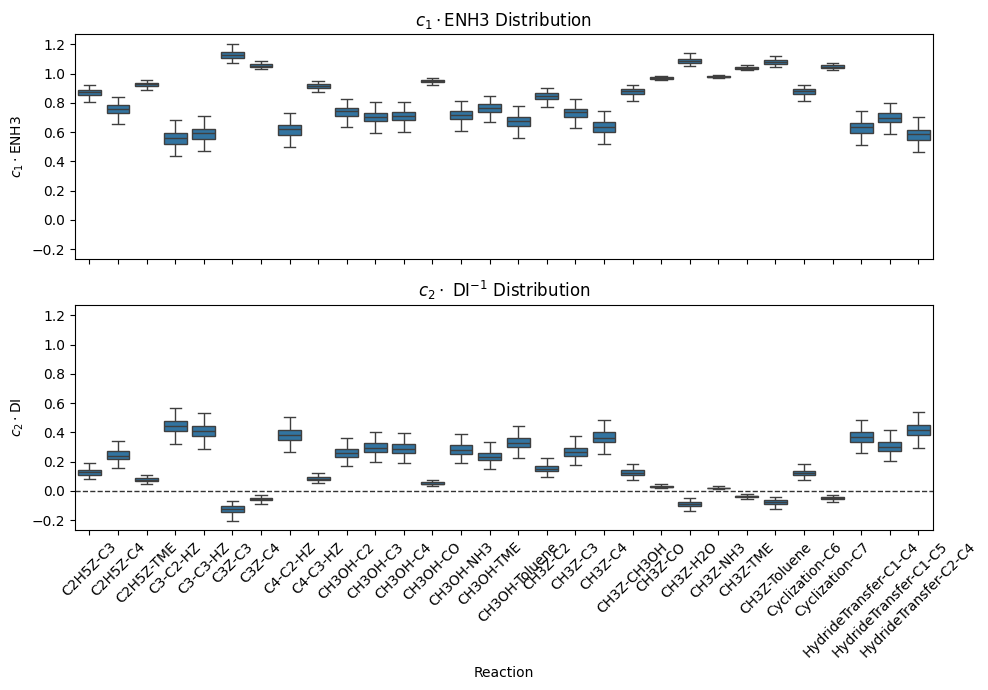

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

# 读取文件
df_pred = pd.read_csv("./fix/train_predictions_2.csv")
df_coef = pd.read_csv("./fix/coeffs_2.csv")

# 合并系数
df = df_pred.merge(df_coef[["task", "c0", "c1", "c2"]], on="task", how="left")

# 归一化贡献（分母为 pred_T1 - c0 = contrib_1 + contrib_2）
denom = df["pred_T1"] - df["c0"]
df["norm_c1"] = df["contrib_1"] / denom
df["norm_c2"] = df["contrib_2"] / denom
df.loc[denom == 0, ["norm_c1", "norm_c2"]] = np.nan  # 防止除零

# 拉成长表，只有一列 norm_c 便于画图
df_long = df.melt(
    id_vars=["materials", "task"],
    value_vars=["norm_c1", "norm_c2"],
    var_name="descriptor",
    value_name="norm_c",
)
fig, (ax1, ax2) = plt.subplots(
    2, 1, sharex=True, figsize=(10, 7)
)
# -------------------------
#       上方：contrib_2
# -------------------------

sns.boxplot(x="task", y="norm_c1", data=df, ax=ax1, showfliers=False)
ax1.set_title(r"$c_1 \cdot $ENH3 Distribution")
tasks = df["task"].unique()
# 标注IQR
# for i, task in enumerate(tasks):
#     sub = df[df_long["task"] == task]["norm_c1"].dropna()
#     Q1 = np.percentile(sub, 25)
#     Q3 = np.percentile(sub, 75)
#     IQR = Q3 - Q1
#     ax1.text(i, sub.max() + 0.02, f"{IQR:.2f}", ha="center", fontsize=8)

# -------------------------
#       下方：contrib_1
# -------------------------
    
sns.boxplot(x="task", y="norm_c2", data=df, ax=ax2, showfliers=False)
ax2.set_title(r"$c_2 \cdot$ DI$^{-1}$ Distribution")

# 标注IQR

# for i, task in enumerate(tasks):
#     sub = df[df["task"] == task]["contrib_1"].dropna()
#     Q1 = np.percentile(sub, 25)
#     Q3 = np.percentile(sub, 75)
#     IQR = Q3 - Q1
#     ax2.text(i, sub.max() + 0.02, f"{IQR:.3f}", ha="center", fontsize=8)

ax2.axhline(
    0,
    linestyle="--",
    color="black",
    linewidth=1,
    alpha=0.8
)
ymin, ymax = df[["norm_c1", "norm_c2"]].stack().agg([np.nanmin, np.nanmax])
ax1.set_ylim(ymin, ymax)
ax2.set_ylim(ymin, ymax)
ax2.set_ylabel(r"$c_2 \cdot \mathrm{DI}$")
ax1.set_ylabel(r"$c_1 \cdot \mathrm{ENH3}$")
# ax2.set_xlabel("Task", fontsize = 12)
# 公用 x 轴标签
plt.xticks(rotation=45, fontsize=10)
plt.xlabel("Reaction")
plt.tight_layout()
plt.show()

 task C2H5Z-C3 occurs error! 1.204990726
 task C2H5Z-C4 occurs error! 1.104356347
 task C2H5Z-TME occurs error! 0.5026387858
 task C3-C2-HZ occurs error! 1.623925646
 task C3-C3-HZ occurs error! 1.272137652
 task C3Z-C3 occurs error! 0.6856571274
 task C3Z-C4 occurs error! 0.6016790992
 task C4-C2-HZ occurs error! 1.213140353
 task C4-C3-HZ occurs error! 0.481428001
 task CH3OH-C2 occurs error! 1.974865042
 task CH3OH-C3 occurs error! 1.682222713
 task CH3OH-C4 occurs error! 1.330103157
 task CH3OH-CO occurs error! 1.868444448
 task CH3OH-NH3 occurs error! 1.413835857
 task CH3OH-TME occurs error! 0.840483046
 task CH3OH-Toluene occurs error! 1.50875113
 task CH3Z-C2 occurs error! 1.963684476
 task CH3Z-C3 occurs error! 1.762103208
 task CH3Z-C4 occurs error! 1.710813222
 task CH3Z-CH3OH occurs error! 1.431416366
 task CH3Z-CO occurs error! 1.916460109
 task CH3Z-H2O occurs error! 1.596629294
 task CH3Z-NH3 occurs error! 1.089013888
 task CH3Z-TME occurs error! 0.7695248603
 task CH3Z-

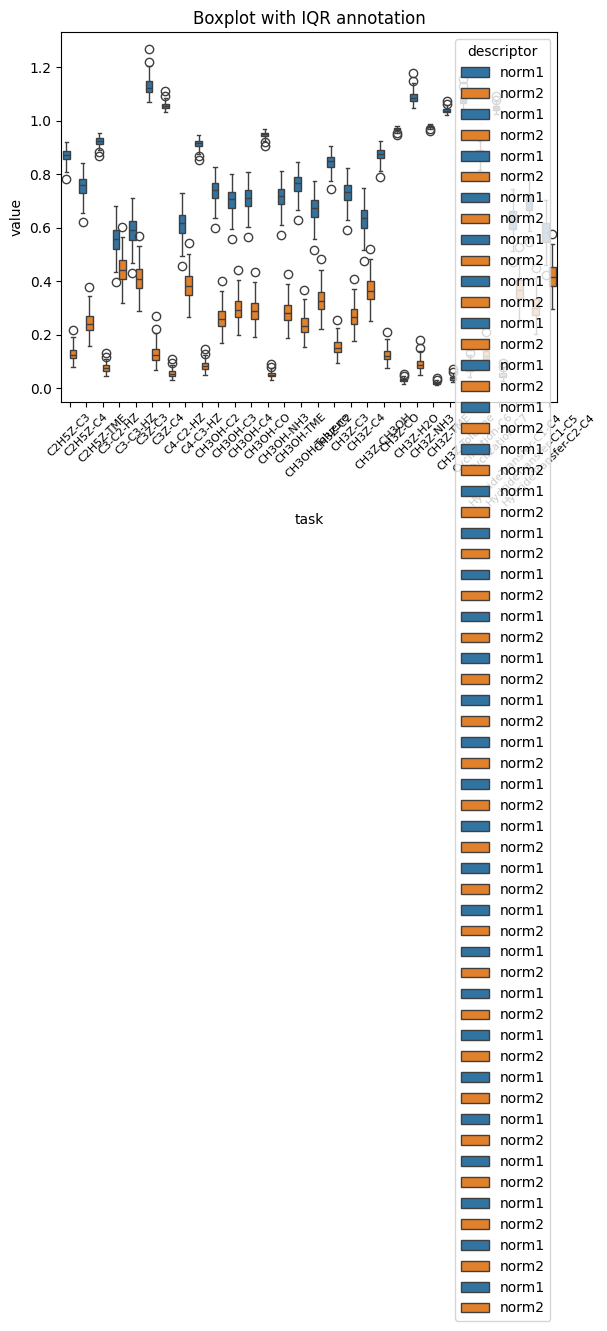

In [90]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path


pred_path = Path("./fix/train_predictions_2.csv")
coef_path = Path("./fix/coeffs_2.csv")

df_pred = pd.read_csv(pred_path)
df_coef = pd.read_csv(coef_path)
# plt.figure(figsize=(10,6))
# ax = sns.boxplot(x="task", y="contrib_2", data=df_pred)

# 开始逐 task 标注 IQR
tasks = df_pred["task"].unique()

for i, task in enumerate(tasks):
    c0 = float(df_coef.loc[df_coef["task"] == task,"c0"].iloc[0])
    sub = df_pred[df_pred["task"] == task].dropna()
    sub["norm1"] = np.abs(sub["contrib_1"] / (sub["pred_T1"] - c0))
    sub["norm2"] = np.abs(sub["contrib_2"] / (sub["pred_T1"] - c0))
    df_long = pd.melt(
    sub,
    id_vars=["task"],
    value_vars=["norm1", "norm2"],
    var_name="descriptor",
    value_name="value"
)
    ax = sns.boxplot(
    x="task",
    y="value",
    hue="descriptor",
    data=df_long
)
    # print(sub.head())
    try:
        Q1 = np.percentile(sub, 25)
        Q3 = np.percentile(sub, 75)
        IQR = Q3 - Q1
    # print(sub.max())
        # 标注在箱体上方（y 坐标略高于箱体）
        ax.text(
            i, 
            sub.max()+0.01,        # 在 Q3 再往上偏一点
            f"{IQR:.3f}",
            ha="center",
            fontsize=8
        )
    except:
        print(f" task {task} occurs error! {c0}")
plt.xticks(rotation=45,fontsize=8)
plt.title("Boxplot with IQR annotation")
plt.show()

Text(0.5, 0, 'conribute_ENH3')

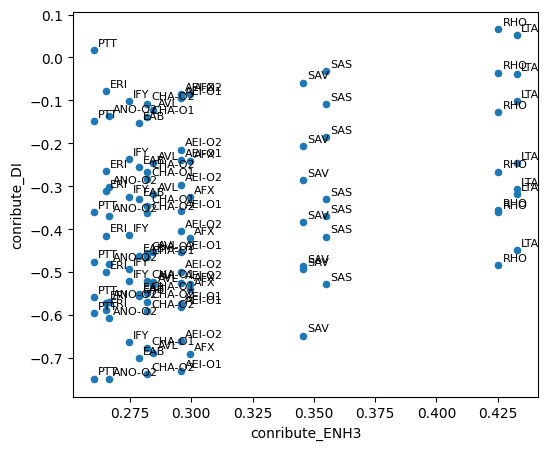

In [141]:
fig, ax2d = plt.subplots(figsize=(6, 5))
ax2d.scatter(df_task["contrib_2"], df_task["pred_T1"], color="tab:blue", s=20, label="pred data")
for x, y, label in zip(df_task["contrib_2"], df_task["pred_T1"], df_task["zeotype"]):
    ax2d.annotate(str(label), (x, y), textcoords="offset points", xytext=(3, 3), fontsize=8)
ax2d.set_ylabel("conribute_DI"); ax2d.set_xlabel("conribute_ENH3")



task
C2H5Z-C4    1.027527
dtype: float64


/var/folders/36/gl3ryvx95t9404brkphk8v680000gn/T/ipykernel_27588/357274242.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: np.polyfit(x["d1"], x["true_T1"], 1)[0])


Text(0.06242133139670717, 0.5, 'y')

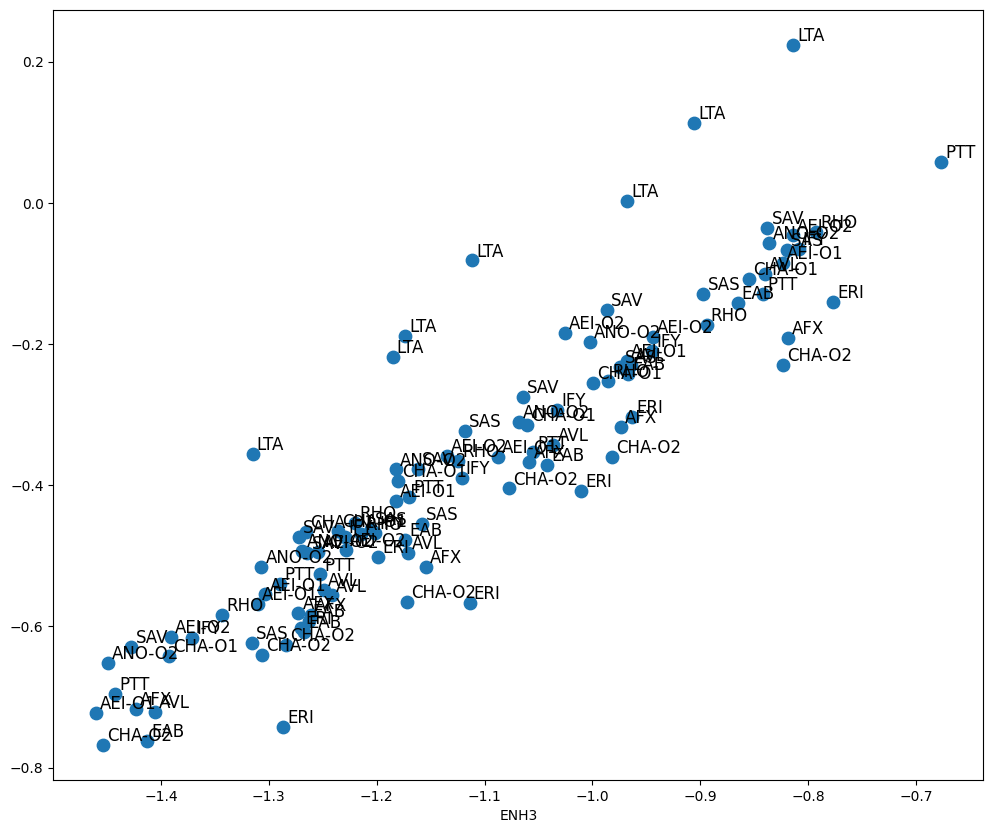

In [146]:
fig, ax2d = plt.subplots(figsize=(12, 10))
ax2d.scatter(df_task["contrib_1"], df_task["true_T1"], color="tab:blue", s=80, label="pred data")
for x, y, label in zip(df_task["contrib_1"], df_task["true_T1"], df_task["zeotype"]):
    ax2d.annotate(str(label), (x, y), textcoords="offset points", xytext=(3, 3), fontsize=12)
slopes = (
    df_task.groupby("task")
      .apply(lambda x: np.polyfit(x["d1"], x["true_T1"], 1)[0])
)
print(slopes)
ax2d.set_xlabel("ENH3"); ax3d.set_ylabel("y")

Text(0.06672312424751077, 0.5, 'y')

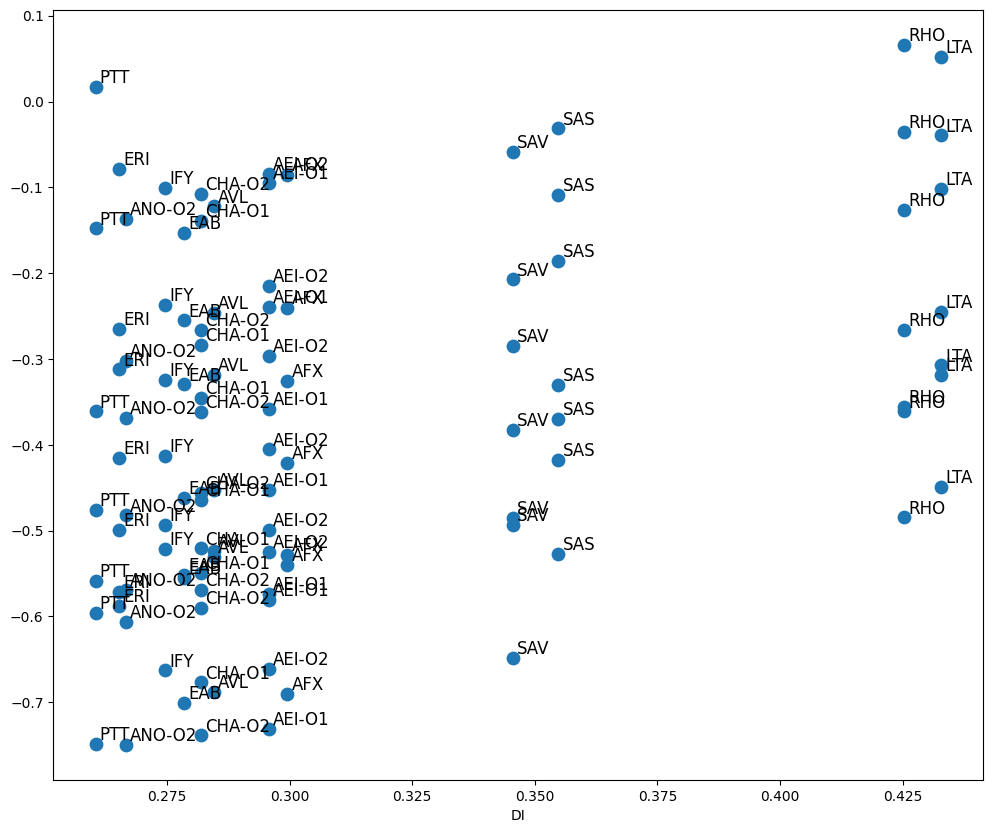

In [7]:
fig, ax2d = plt.subplots(figsize=(12, 10))
ax2d.scatter(df_task["contrib_2"], df_task["pred_T1"], color="tab:blue", s=80, label="pred data")
for x, y, label in zip(df_task["contrib_2"], df_task["pred_T1"], df_task["zeotype"]):
    ax2d.annotate(str(label), (x, y), textcoords="offset points", xytext=(3, 3), fontsize=12)
ax2d.set_xlabel("DI"); ax3d.set_ylabel("y")

2 2


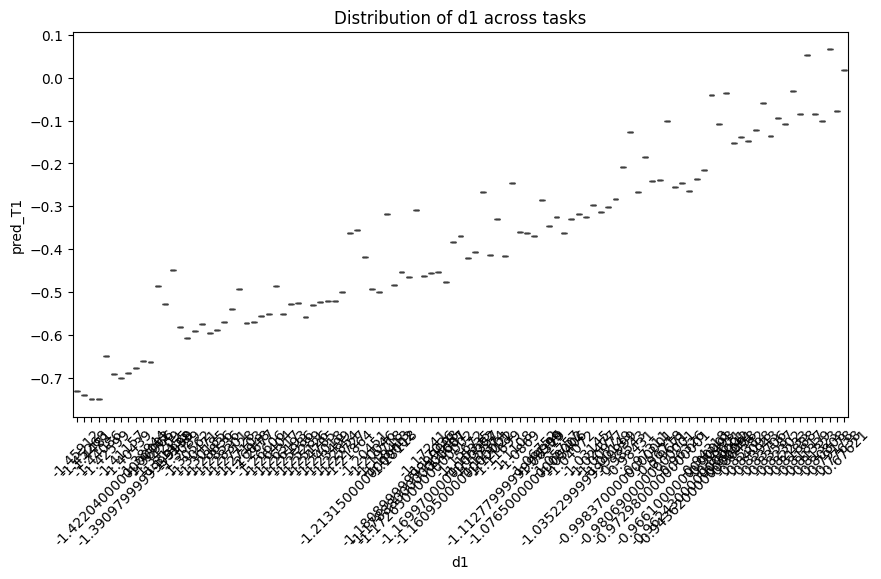

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from mt_sisso_scatter import _build_task_index
# 配置
selected_task = "C2H5Z-C4"  # 修改为你要看的 task
pred_path = Path("train_predictions.csv")
coef_path = Path("coeffs.csv")

# 读数据
df_pred = pd.read_csv(pred_path)
df_coef = pd.read_csv(coef_path)


# 过滤 task
df_task = df_pred[df_pred["task"] == selected_task].copy()
if df_task.empty:
    raise SystemExit(f"{selected_task} 在 train_predictions.csv 中没有数据")
row_coef = df_coef[df_coef["task"] == selected_task]
if row_coef.empty:
    raise SystemExit(f"{selected_task} 在 coeffs.csv 中没有系数")
# 提取系数与贡献
coef_row = row_coef.iloc[0]
c0 = float(coef_row["c0"])
# 动态获取所有 contrib_i 与对应 ci
contrib_cols = [c for c in df_task.columns if c.startswith("contrib_")]
ci_cols = [c for c in coef_row.index if c.startswith("c") and c != "c0"]
print(len(contrib_cols),len(ci_cols))
if len(contrib_cols) < 2 or len(ci_cols) < 2:
    raise SystemExit("至少需要 c1/c2 和 contrib_1/contrib_2")

df_task["zeotype"] = [m.split('_')[0] for m in df_task['materials'] ]
df_task["mtype"] = [m.split('_')[1] for m in df_task['materials'] ]


c1 = float(coef_row["c1"]); c2 = float(coef_row["c2"])
d1 = df_task["contrib_1"] / c1
d2 = df_task["contrib_2"] / c2
df_task["d1"] = d1  #ENH3
df_task["d2"] = d2  ##DI
plt.figure(figsize=(10, 5))
sns.boxplot(x="d1", y="pred_T1", data=df_task)
plt.title("Distribution of d1 across tasks")
plt.xticks(rotation=45)
plt.show()